In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import pickle
import pandas as pd
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from imutils import paths
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
!cp -r "/content/drive/MyDrive/Asian_Face_Age" /content/dataset

In [52]:
# Cấu hình
args = {
    "image_dir": r"dataset/Data_all",
    "label_csv": r"dataset/Data_label.csv",
    "model_path": "/content/drive/MyDrive/VN_Age_models/model_VN_Age.h5",
    "label_encoder_path": "/content/drive/MyDrive/VN_Age_models/age_label_encoder.pkl",
    "class_labels_path": "/content/drive/MyDrive/VN_Age_models/age_range_labels.pkl"
}



In [53]:
# === Bộ tiền xử lý ảnh (resize) ===
class SimplePreprocessor:
    def __init__(self, width, height, inter=cv2.INTER_AREA):
        self.width = width
        self.height = height
        self.inter = inter

    def preprocess(self, image):
        return cv2.resize(image, (self.width, self.height), interpolation=self.inter)

# === Hàm ánh xạ tuổi sang khoảng tuổi ===
def age_to_range(age):
    age = float(age)
    if age < 5:
      return "1-4"
    elif age < 11:
        return "5-10"
    elif age < 16:
        return "10-15"
    elif age < 21:
        return "15-20"
    elif age < 26:
        return "20-25"
    elif age < 31:
        return "25-30"
    elif age < 41:
        return "30-40"
    elif age < 51:
        return "40-50"
    elif age < 61:
        return "50-60"
    elif age < 71:
        return "60-70"
    else:
        return "70-80"

# === Hàm vẽ phân bố nhãn ===
def plot_label_distribution(labels, title="Phân bố nhãn"):
    label_series = pd.Series(labels)
    counts = label_series.value_counts().sort_index()
    print("Phân bố nhãn:")
    print(counts)
    plt.figure(figsize=(8, 5))
    counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(title)
    plt.xlabel("Khoảng tuổi")
    plt.ylabel("Số lượng mẫu")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# === Load và xử lý dữ liệu ===
print("[INFO] Đang tải nhãn...")
labels_df = pd.read_csv(args["label_csv"])
labels_df = labels_df.dropna(subset=["Age"])
labels_df["Age_Range"] = labels_df["Age"].apply(age_to_range)
filename_to_label = dict(zip(labels_df["Img"], labels_df["Age_Range"]))

[INFO] Đang tải nhãn...


In [54]:
labels_df.head(20)

,Img,Age,Gender,Quality,Face angle,Age_Range
0,img1,3.0,Boy,Normal,Straight,1-4
1,img2,4.0,Girl,Normal,Straight,1-4
2,img3,2.0,Girl,Poor,Straight,1-4
3,img4,4.0,Girl,Normal,Straight,1-4
4,img5,3.0,Girl,Normal,Right,1-4
5,img6,1.0,Girl,Good,Straight,1-4
6,img7,3.0,Boy,Good,Left,1-4
7,img8,2.0,Boy,Poor,Straight,1-4
8,img9,1.0,Boy,Poor,Straight,1-4
9,img10,1.0,boy,Poor,Straight,1-4


[INFO] Đang tải ảnh...
[INFO] Tải 247 ảnh thành công.
Phân bố nhãn:
1-4      19
10-15    30
15-20    20
20-25    20
25-30    21
30-40    21
40-50    24
5-10     22
50-60    28
60-70    14
70-80    28
Name: count, dtype: int64


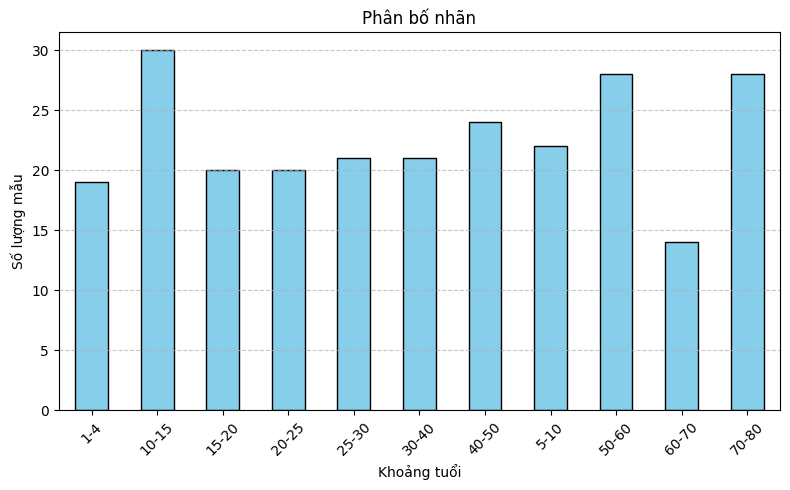

[INFO] Đã lưu label encoder và class labels.


In [55]:
print("[INFO] Đang tải ảnh...")
imagePaths = list(paths.list_images(args["image_dir"]))
sp = SimplePreprocessor(100, 100)
data, labels = [], []

for path in imagePaths:
    filename = os.path.splitext(os.path.basename(path))[0]
    if filename in filename_to_label:
        image = cv2.imread(path)
        if image is None: continue  # Bỏ ảnh hỏng
        image = sp.preprocess(image)
        data.append(image)
        labels.append(filename_to_label[filename])

data = np.array(data, dtype="float32") / 255.0
labels = np.array(labels)

print(f"[INFO] Tải {len(data)} ảnh thành công.")
plot_label_distribution(labels)

# === Mã hóa nhãn ===
le = LabelEncoder()
labels_enc = le.fit_transform(labels)
labels_cat = to_categorical(labels_enc)
num_classes = labels_cat.shape[1]

# === Tách tập train/test ===
#(trainX, testX, trainY, testY) = train_test_split(data, labels_cat, test_size=0.2, random_state=42)

# === Lưu label encoder và danh sách nhãn ===
os.makedirs("/content/drive/MyDrive/VN_Age_models", exist_ok=True)
with open(args["label_encoder_path"], "wb") as f:
    pickle.dump(le, f)
with open(args["class_labels_path"], "wb") as f:
    pickle.dump(le.classes_.tolist(), f)
print("[INFO] Đã lưu label encoder và class labels.")


In [56]:
# === Định nghĩa mô hình CNN ===
def cnn_model(input_shape=(100, 100, 3), num_classes=num_classes):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.6))
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [57]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(validation_split=0.8)

train_generator = train_datagen.flow(
    data,
    labels_cat,
    batch_size=32,
    subset="training"
)

val_generator = val_datagen.flow(
    data,
    labels_cat,
    batch_size=32,
    subset="validation"
)

In [58]:
# === Huấn luyện hoặc tải mô hình ===
if os.path.exists(args["model_path"]):
    print("[INFO] Loading existing model...")
    model = load_model(args["model_path"])
else:
    print("[INFO] Training model...")
    model = cnn_model()


    earlystop = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, verbose=1)

    history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=100,
                    callbacks=[earlystop],
                    verbose=1)
    model.save(args["model_path"])
    print("[INFO] Saved model to", args["model_path"])

[INFO] Training model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.1071 - loss: 3.7653 - val_accuracy: 0.1015 - val_loss: 2.6801
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.1773 - loss: 3.2519 - val_accuracy: 0.1015 - val_loss: 2.7436
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.1115 - loss: 3.5917 - val_accuracy: 0.1015 - val_loss: 2.7974
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.1907 - loss: 3.0486 - val_accuracy: 0.1015 - val_loss: 2.8215
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.1960 - loss: 3.0618 - val_accuracy: 0.0863 - val_loss: 2.8244
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.2581 - loss: 2.8481 - val_accuracy: 0.0761 - val_loss: 2.8416
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.2714 - loss: 2.7678 - val_accuracy: 0.0761 - val_loss: 2.8435
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.2093 - loss: 3.0276 - val_accuracy: 0.1066 - val_loss: 2.8349
Epoch 9/100


[INFO] Saved model to /content/drive/MyDrive/VN_Age_models/model_VN_Age.h5


In [60]:
# === Đánh giá ===
(loss, acc) = model.evaluate(val_generator, verbose=0)
print(f"Độ chính xác trên tập test: {acc * 100:.2f}%")

Độ chính xác trên tập test: 27.41%


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 850ms/step


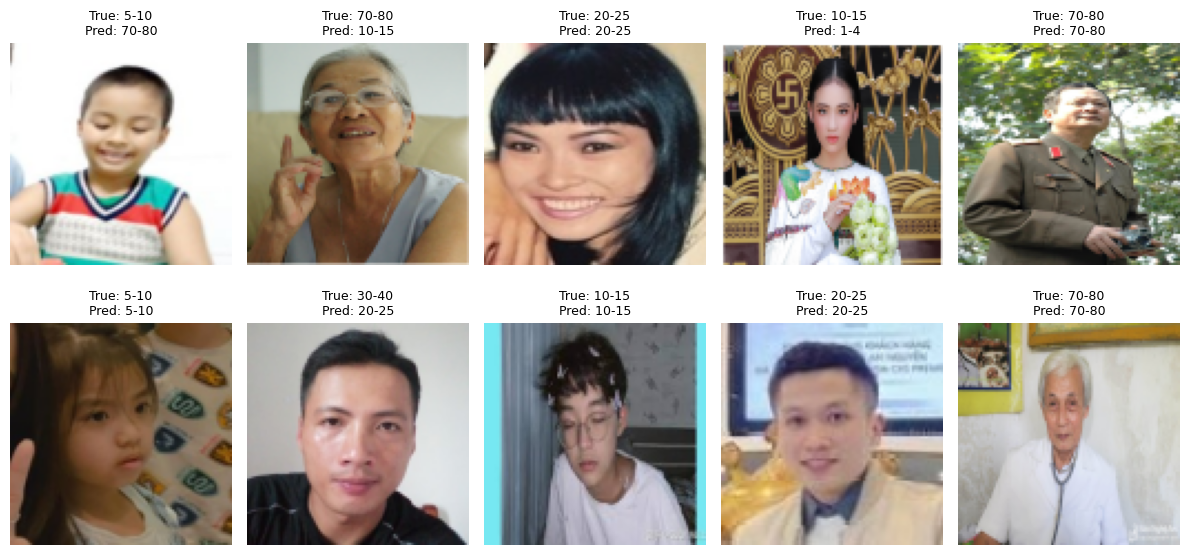

In [61]:
# === Dự đoán mẫu và hiển thị ===
import random

# lấy 1 batch từ validation generator
images, labels = next(val_generator)

# dự đoán
preds = model.predict(images)

# chọn 10 ảnh ngẫu nhiên
idxs = random.sample(range(len(images)), 10)

plt.figure(figsize=(12,6))

for i, idx in enumerate(idxs):

    img = (images[idx] * 255).astype("uint8")

    true_label = np.argmax(labels[idx])
    pred_label = np.argmax(preds[idx])

    plt.subplot(2,5,i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.title(
        f"True: {le.classes_[true_label]}\nPred: {le.classes_[pred_label]}",
        fontsize=9
    )

plt.tight_layout()
plt.show()
